# Chapter 7 — Strategy Taxonomy: Where Edges Come From

Chapter 6 gave us a working intraday data substrate and three pictures: the QQQ U-shape, the FOMC overlay, and time vs dollar bars. Ch8 will build a fully runnable mean-reversion strategy on QQQ end-to-end. Ch7 is the conceptual hinge between them: *before* you build a strategy, what is the question you should be asking, and what are the categories of answer?

This is the first chapter that doesn't run a backtest, doesn't fit a model, and barely uses any new statistics. The whole math budget is one autocorrelation curve. The point is to teach the reader to interrogate any candidate strategy with the question **"where does the edge come from, mechanically?"** — and to recognize when an edge is real versus when a chart pattern is a fitted artifact.

## Three things this chapter teaches you to ask

1. **Is this edge conditional, not universal?** Every viable strategy has a positive expectancy per trade *in some set of conditions* and not others. Knowing the conditions is the strategy; the recipe is downstream. Edges decay; treat any historical edge as decaying unless proven otherwise.
2. **What is the mechanism?** Strategies cluster into four canonical families named by *why they work mechanically*, not by the chart pattern they produce: mean reversion, momentum / trend, breakout, event-driven. Each family has a specific reason it works (when it does) and specific reasons it fails (when it does).
3. **At what horizon, in what regime?** The same return series can be mean-reverting at 5-minute horizons and trending at 1-day horizons. Nothing about a market is universally true. The right question is always "at what horizon, in what regime."

## §1 — What is an edge?

The only operational definition of an edge is **positive expectancy per trade after costs**, in some defined regime. Every other definition you'll hear — "high win rate," "low drawdown," "great Sharpe," "consistent profit factor" — either implies expectancy or fails to capture it.

Three quantities worth knowing precisely:

**Expectancy per trade**

> *E* = *p* · *w* − (1 − *p*) · *l*

where:
- *p* = hit rate (fraction of trades closed at a profit, before costs)
- *w* = average winning trade in some unit (dollars, percent, *R*-units)
- *l* = average losing trade in the same unit, expressed as a positive number
- *E* > 0 → the strategy makes money in expectation; *E* < 0 → it bleeds

**Profit factor**

> PF = (gross winnings) / (gross losses)

PF > 1 means the strategy is profitable; PF > 2 is strong; PF > 3 over a meaningful sample raises curve-fit suspicion (real strategies don't usually do that well over thousands of trades).

**Payoff ratio**

> *R*<sub>p</sub> = *w* / *l*

How big winners are relative to losers. A "1.5R payoff" means winners average 1.5× the size of losers.

### Setup

Before working the empirical hook in §6, load Ch6's QQQ minute parquet, filter to RTH, and build minute log returns. Zero out the first bar of each session — there's no intraday return at the session boundary, only the overnight gap.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CH6_CACHE = Path("../06-bridge-to-intraday/data")
qqq = pd.read_parquet(CH6_CACHE / "qqq_1min.parquet")
# Convert UTC timestamps from the cache to ET so session boundaries line up.
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
# Encode each bar's clock time as minutes-from-midnight for cheap window filters.
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN, RTH_CLOSE = 9 * 60 + 30, 16 * 60
# Keep only Regular Trading Hours; the half-open window mirrors how exchanges count bars.
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
# Re-index time as 0..389 within each RTH session for groupby/bucket logic later.
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN
# Date label per session — used to group bars by trading day.
rth["session_date"] = rth.index.normalize()
# Intraday log returns: ln(close_t / close_{t-1}).
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))
# First bar of each session has a return spanning the overnight gap; null it
# so within-session statistics aren't contaminated by overnight moves.
sf = rth.groupby("session_date").head(1).index
rth.loc[sf, "log_ret"] = np.nan
print(f"RTH bars: {len(rth):,}  sessions: {rth['session_date'].nunique()}")


RTH bars: 95,318  sessions: 251


### The pedagogical worked example

Three hypothetical strategies, expectancies in *R*-units (where 1*R* is the average loss size, so *l* = 1):

| Hit rate (*p*) | Payoff (*w*) | Expectancy (*E*) |
|---|---|---|
| 0.55 | 0.9 | **+0.045** |
| 0.70 | 0.3 | **−0.09** |
| 0.30 | 3.0 | **+0.20** |

The middle row is the trap. A 70% hit rate *sounds* like it should be a great strategy. It's not — the payoff ratio of 0.30 means winners are too small to cover losers, and you bleed at −0.09*R* per trade. Sell 100 trades and you've lost 9*R* in expectation.

Conversely, the bottom row looks miserable on hit rate alone — you're wrong 70% of the time — but every winner is 3× the size of a loser, and the expectancy is +0.20*R*, the strongest of the three. Trend and breakout strategies live in this regime: low hit rate, high payoff. Mean-reversion strategies live in the top regime: high hit rate, low payoff. Both are viable. Both can be unprofitable if the numbers don't multiply correctly.

Computed directly:

In [2]:
rows = []
# Expectancy in R-units: E = p*W - (1-p)*L, with L=1 by R-multiple convention.
# Three illustrative profiles: balanced, high-hit-rate-small-payoff, low-hit-rate-large-payoff.
for hr, payoff in [(0.55, 0.9), (0.70, 0.3), (0.30, 3.0)]:
    e = hr * payoff - (1 - hr) * 1.0
    rows.append({"hit_rate": hr, "payoff": payoff, "expectancy_R": round(e, 4)})
pd.DataFrame(rows)


,hit_rate,payoff,expectancy_R
0,0.55,0.9,0.045
1,0.70,0.3,-0.090
2,0.30,3.0,0.200


### The cost subtraction

Realistic round-trip costs on liquid US equity ETFs at retail are roughly **0.5 to 2 basis points** (0.005% to 0.02%) per trade — half-spread plus exchange fees plus slippage. Ch12 makes this honest with explicit cost models.

If your *R* is small — say winners average 0.10% on QQQ — then a 0.5 bp round-trip cost is 5% of your *R*. A +0.045*R* edge becomes +0.045 − 0.005 = +0.040*R* per trade. That's still positive, but a strategy with the same +0.045*R* edge that places **30 trades per session** (instead of 3) and costs **2 bp per round-trip** loses 0.020*R* per trade to costs and the headline collapses.

> **The usual shape of an unprofitable retail strategy:** a small positive expectancy multiplied by enough trades and big enough costs to flip negative. High-frequency, low-edge strategies are the most cost-sensitive; low-frequency, high-payoff strategies are the most cost-tolerant. **Always do the cost arithmetic before the backtest.**

Ch9 makes you compute these on real backtest trades. Ch11 makes you do it with walk-forward discipline. Ch12 takes a 0.5 bp slippage chunk out and watches the headline collapse.

## §2 — Mean reversion

**Mechanism.** Liquidity providers — market makers, electronic HFT firms — make money from fading overshoots back toward fair value. When price moves away from fair value faster than information justifies, providers post offsetting orders, get filled at the temporary extreme, and earn the spread plus the small reversion that follows. At intraday horizons, this dynamic is dominant in liquid instruments because most "moves" are noise around fair value, not new information.

The retail-friendly version of the same mechanism: anytime QQQ has a noticeable move with no news driving it, there's some chance it'll partially un-do that move in the next 1–30 minutes. You're not competing with HFTs at the millisecond layer (you'd lose); you're harvesting the residual reversion that's left over after they've taken their cut.

**When it works:**
- Liquid, deep order books (large-cap ETFs, S&P 500 names)
- Quiet news days
- Intraday horizons (seconds to tens of minutes)
- Windows where the U-shape is not in its most aggressive segment

**When it fails:**
- Trending regimes — when information genuinely dominates noise
- Around scheduled events (FOMC, CPI, NFP)
- Illiquid instruments where there's no liquidity-provider population to mean-revert against
- Immediately after the open, when overnight information is still being absorbed

**Concrete example.** "QQQ moves 0.4% in 10 minutes mid-session with no news driving it. I expect partial reversion in the next 10–30 minutes." This is the mechanism Ch8 will turn into a runnable strategy.

## §3 — Momentum / trend

**Mechanism.** Information diffuses slowly. Large institutional orders are sliced over hours or days (TWAP, VWAP, implementation-shortfall execution) to minimize market impact, which means the price keeps moving in the direction of the order long after the news has hit. Behavioral biases reinforce: investors anchor on prior prices and underreact to fresh news; once enough have noticed, they overreact and FOMO in. The combined effect is positive autocorrelation of returns at the right horizon.

**When it works:**
- Daily and multi-day horizons
- News-driven moves
- Emerging trends with clear confirmation
- Assets where institutional flow is large relative to retail noise

**When it fails:**
- Range-bound markets (no trend to follow)
- Horizons where execution is faster than information diffusion (sub-minute on liquid ETFs)
- After the move has already been fully chased — late retail FOMO is the bag-holder phase

**Concrete example.** "Stock gaps +5% on an earnings beat. Institutions can't fill their full position at the open without moving the price; they slice over the next several days. The drift continues for 2-4 days post-earnings."

**Important caveat.** *Momentum at sub-session horizons on liquid index ETFs is much harder to find than mean-reversion.* On QQQ minute bars, the §6 empirical hook will show strongly negative autocorrelation at short lags — meaning intraday momentum, if it exists at all on this instrument, lives at horizons of an hour or more, not minutes. This is precisely why our first runnable strategy (Ch8) is mean-reversion, not momentum.

## §4 — Breakout

**Mechanism.** Price compresses into a range as buyers and sellers find a temporary equilibrium. Stops cluster on both sides of the range — short stops above the high, long stops below the low. Once the range breaks for any reason (news, large order, just enough random noise to push through), the stops on the wrong side trigger and create a self-reinforcing cascade: stop-hits → market orders → further price movement → more stops. Breakouts are part information (new info justifies a new range) and part mechanical (stop-runs amplify the move beyond what the information alone would justify).

**When it works:**
- Periods of clear range compression followed by a catalyst
- Instruments where stops cluster visibly (round numbers, prior highs/lows, opening range, options strike levels)
- Event-driven setups when the event resolves the compression

**When it fails:**
- Choppy markets where the "range" was actually noise around a longer trend
- Instruments without obvious technical levels for stops to cluster at
- *Fakeouts* — breakouts that reverse immediately after triggering the initial wave of stops; the market making firms know exactly where retail stops sit

**Concrete example.** "QQQ trades in a 0.5% range for two hours pre-FOMC. The range itself is the market expressing uncertainty about the upcoming announcement. When the announcement hits at 14:00 ET, the range breaks; stops on the wrong side cascade; the post-announcement move is several times larger than the pre-announcement range." This example is deliberately the bridge to event-driven (§5) — breakout setups around scheduled events combine both mechanisms.

## §5 — Event-driven

**Mechanism.** Scheduled news creates an *expected* variance window. The entire market knows information is arriving at a specific time; vol is structurally elevated for some minutes around the print. Strategies trade either (a) the announcement itself — hard, because direction is unknown, or (b) the post-announcement reversion or continuation pattern — usually easier, because the *vol regime* is the predictable part even when direction isn't.

**When it works:**
- Scheduled events with well-defined time and known information content (FOMC at 14:00 ET, CPI / NFP at 08:30 ET, individual-name earnings at known release time)
- Setups where you can size the position around the *vol regime* rather than betting on direction
- Pairs of related instruments where one reacts faster than the other

**When it fails:**
- Unscheduled events — geopolitical shocks, terror attacks, individual-company news at unknown times. No vol-regime forecast helps.
- When consensus expectation is already priced in and the surprise is small
- When the initial reaction inverts (e.g., "buy the rumor sell the news" patterns)

**Concrete example.** Ch6 §5's headline: at 14:00 ET on FOMC days, QQQ's mean absolute return is **~12.23 bp** vs **~2.73 bp** on non-FOMC days — a **4.49× ratio**. The *vol regime* around FOMC is the edge; what direction to trade is a separate question, and usually a harder one.

## Family-table summary

| Family | Mechanism | When it works | When it fails | First-look horizon |
|---|---|---|---|---|
| Mean reversion | Liquidity providers fade overshoots back to fair value | Liquid, deep books; quiet news; non-extreme intraday windows | Trending regimes; around scheduled events; illiquid instruments | seconds → tens of minutes |
| Momentum / trend | Slow info diffusion + sliced institutional execution + behavioral biases | News-driven moves; multi-day horizons | Range-bound markets; sub-session horizons on liquid ETFs | hours → days |
| Breakout | Range compression → vol expansion + stop-run cascades | Clear pre-breakout compression; visible technical levels | Choppy markets without real ranges; fakeout-prone instruments | varies, often minutes around the break |
| Event-driven | Scheduled news creates an expected variance window | Scheduled events with known time and content | Unscheduled events; consensus already priced in | minutes around the print |

## §6 — Empirical: where the edges live on QQQ

Now we test §2's claim that mean-reversion lives in liquid intraday markets at short horizons. The instrument: QQQ. The data: Ch6's 1-year minute-bar parquet (2025-05-08 → 2026-05-07, 95,318 RTH bars across 251 sessions). The metric: **lag-*k* Pearson autocorrelation** of minute log returns, computed *within each session* and averaged across sessions. Within-session computation keeps the overnight gap from polluting the estimate.

> **Math note: lag-*k* autocorrelation.** ρ<sub>k</sub> = corr(*r*<sub>t</sub>, *r*<sub>t+k</sub>), where *r*<sub>t</sub> is the minute-*t* log return. ρ<sub>k</sub> < 0 → returns at lag *k* tend to *anti-correlate* (mean-reversion). ρ<sub>k</sub> > 0 → returns at lag *k* tend to *co-correlate* (momentum/trend). ρ<sub>k</sub> ≈ 0 → no exploitable structure at that horizon.

where:
- ρ<sub>k</sub> = the lag-*k* autocorrelation coefficient (a Pearson correlation between two time-shifted return series)
- *r*<sub>t</sub> = the log return at minute *t*
- *r*<sub>t+k</sub> = the log return *k* minutes later
- corr( · , · ) = Pearson correlation, computed within session, then averaged across sessions

In [3]:
def autocorr_within_session(grouped, lag):
    """Mean lag-k autocorrelation across sessions, computed *within* each session
    (no cross-session pairs — the overnight gap doesn't belong in the lag)."""
    rs = []
    for _, s in grouped:
        s = s.dropna()
        # Need enough bars for a stable per-session correlation.
        if len(s) < lag + 30:
            continue
        # Pair each bar with the bar k steps later within the same session.
        a, b = s.iloc[:-lag].values, s.iloc[lag:].values
        # Skip degenerate sessions (all-zero returns) — corrcoef would be NaN.
        if a.std() == 0 or b.std() == 0:
            continue
        rs.append(np.corrcoef(a, b)[0, 1])
    return float(np.mean(rs)), len(rs)


### The lag-*k* curve

| Lag (min) | ρ (QQQ) |
|---|---|
| 1   | **−0.0282** |
| 5   | −0.0087 |
| 15  | −0.0089 |
| 30  | −0.0078 |
| 60  | −0.0021 |
| 120 | **+0.0043** |

Computed below:

In [4]:
LAGS = [1, 5, 15, 30, 60, 120]
# Pre-materialize the (date, returns) groups once so each lag reuses the same split.
grouped = list(rth.groupby("session_date")["log_ret"])
# Sweep a range of lags; sign tells you mean-reversion (negative) vs momentum (positive).
auto_all = {k: autocorr_within_session(grouped, k)[0] for k in LAGS}
pd.Series(auto_all, name="rho_qqq").to_frame()


,rho_qqq
1,-0.028168
5,-0.008731
15,-0.008911
30,-0.007757
60,-0.002115
120,0.004336


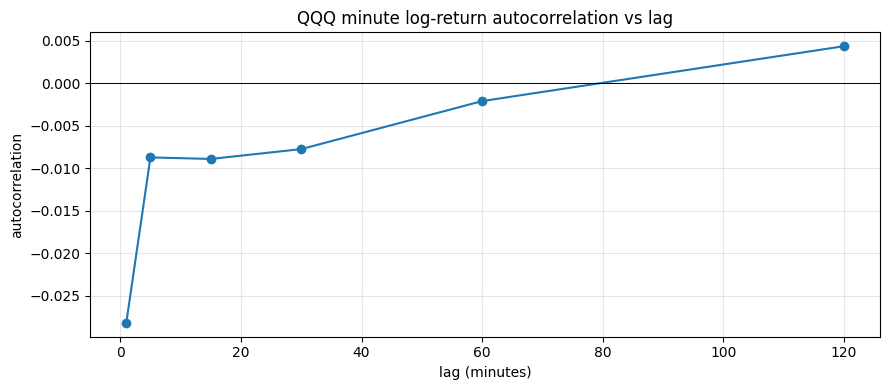

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(auto_all.keys()), list(auto_all.values()), marker="o")
ax.axhline(0, color="black", lw=0.7)
ax.set_xlabel("lag (minutes)")
ax.set_ylabel("autocorrelation")
ax.set_title("QQQ minute log-return autocorrelation vs lag")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


What this curve says:
- **Lag 1 is meaningfully negative** (−0.028). A positive minute bar tends to be followed by a negative minute bar. That's the signature of liquidity providers fading overshoots — exactly §2's mechanism.
- **The effect attenuates rapidly.** By lag 5 the magnitude has dropped 3×; by lag 60 it's essentially gone.
- **Lag 120 flips slightly positive** (+0.004). Two-hour-ahead minute returns weakly co-correlate — the early hint of trend continuation at longer intraday horizons. Not big enough to trade alone, but consistent with the §3 momentum mechanism kicking in once enough information has diffused.

So the autocorrelation curve says, on this 1-year QQQ window: **mean-reversion at the 1-minute horizon is real, momentum at the 2-hour horizon may be real, and there's a wide quiet zone between them.** Strategies in either family need to pick a horizon that lines up with the mechanism.

### Time-of-session conditioning

The all-RTH curve averages across very different parts of the session. Splitting lag-1 by time-of-session bucket:

| Bucket | Lag-1 ρ | Sessions |
|---|---|---|
| Opening 30 min (0–29)    | −0.0351 | 251 |
| Midday (60–299)          | −0.0346 | 251 |
| **Closing 30 min (360–389)** | **−0.0668** | 248 |

Computed below:

In [6]:
def bucket_autocorr(df, mask, lag):
    """Same within-session lag-k autocorr as above, but on a boolean-masked subset
    of bars (e.g. only the opening 30 minutes)."""
    sub = df[mask]
    rs = []
    for _, s in sub.groupby("session_date")["log_ret"]:
        s = s.dropna()
        if len(s) < lag + 5:
            continue
        a, b = s.iloc[:-lag].values, s.iloc[lag:].values
        if a.std() == 0 or b.std() == 0:
            continue
        rs.append(np.corrcoef(a, b)[0, 1])
    return float(np.mean(rs)) if rs else float("nan"), len(rs)

# Three time-of-day buckets within an RTH session (0 = open, 389 = last RTH bar).
buckets = {
    "opening 30 min (0-29)":  rth["minute_of_session"].between(0, 29),
    "midday (60-299)":         rth["minute_of_session"].between(60, 299),
    "closing 30 min (360-389)": rth["minute_of_session"].between(360, 389),
}
pd.DataFrame(
    [{"bucket": name, "rho_lag1": round(bucket_autocorr(rth, mask, 1)[0], 5),
      "n_sessions": bucket_autocorr(rth, mask, 1)[1]}
     for name, mask in buckets.items()]
)


,bucket,rho_lag1,n_sessions
0,opening 30 min (0-29),-0.03513,251
1,midday (60-299),-0.03464,251
2,closing 30 min (360-389),-0.06684,248


**The closing 30 minutes is where mean-reversion is cleanest** — roughly **2× the magnitude** of either opening or midday. This is the opposite of the textbook story (which says midday is cleanest because it's quietest), and it's an honest empirical finding worth dwelling on.

The likely interpretation: the closing window is not quiet; it's *mechanical*. End-of-day flows — closing-auction orders, **MOC (market-on-close) orders** (market orders queued during the day that execute at the official 4:00 PM ET closing auction price, used heavily by index funds and ETFs to rebalance at the close), and index rebalance trades — create a high-volume environment where liquidity providers can fade overshoots aggressively because there's enough volume to actually do the fading. Midday is *quieter* — fewer overshoots, fewer participants, smaller mean-reversion in absolute magnitude. Opening is contaminated by overnight information absorption, which puts a momentum component on top of the mean-reversion and dilutes the signal.

This is good news for Ch8: the closing window gives a cleaner mean-reversion signal *and* is where capacity (executable size at a given price) is highest. Bad news: it's also where end-of-day mechanical flows are most active, which means the strategy must be careful not to fight the closing auction or MOC pressure on the last few minutes.

> **What if your data disagrees?** If you re-run §6 on a different window and the closing window is *not* the cleanest, that's information. Possible causes: a different vol regime, a window with more event days near the close, a window where index rebalances landed differently. The right move is the one we just made: report what you actually found, name a plausible mechanism, and check whether the result holds out-of-sample. The chapter is teaching the *method* of edge interrogation, not selling a fixed result.

## §7 — Why edges decay

Three drivers worth knowing:

1. **Crowding.** When too many people trade the same edge, the inefficiency that produced it gets arbitraged away. The classic case is equity stat-arb (pairs trading): pre-2010 Sharpes of 2-3 collapsed to 0.5-1 by the mid-2010s as the strategy went mainstream and the spreads it traded compressed. Crowding decay is *capacity-driven* — the more capital chasing the signal, the faster the decay.

2. **Regime change.** A mean-reversion strategy fit during a low-vol regime evaporates when vol regime-shifts upward. A momentum strategy fit during a clear macro trend dies when the trend reverses. Regime change is *state-driven* — the strategy isn't worse, the conditions changed. Ch15 (intraday vol & regime detection) is about catching these transitions.

3. **Parameter drift.** A strategy fit to 2018-2022 data may have been optimized to a regime that no longer exists post-2022 rate hikes. Even with the same family and mechanism, the *parameter values* that worked then no longer work now. Parameter drift is the most insidious decay: you didn't crowd the edge, the regime didn't shift dramatically, but the specific 5-minute lookback window or 1.5σ entry threshold you fit doesn't match current conditions. Ch10/Ch11 (backtesting bias and walk-forward) is largely about not falling for parameter-drift mirages.

> Ch9-11 (the backtesting trio) is largely about distinguishing *"edge that decayed"* from *"edge that was never there in the first place."* They are different failures with different remedies.

## §8 — So what?

Decision rules unlocked by this chapter:

- **Always answer "where does the edge come from, mechanically?" before building.** If you can't articulate a market mechanism in one sentence — liquidity-provision, slow info diffusion, range-compression-and-stop-run, scheduled-vol-window — you are curve-fitting, not edge-finding.
- **A strategy with hit rate 0.70 and payoff 0.30 has expectancy −0.09*R*; ignore hit rate without payoff context.** Hit rate alone is meaningless. Payoff alone is meaningless. Expectancy after costs is the only thing that decides profit.
- **Match horizon to mechanism.** Don't run a momentum strategy at 5-minute resolution on QQQ — the data says it's mean-reverting there. Don't run a mean-reversion strategy across an FOMC announcement — the mechanism reverses.
- **Edges decay; treat any historical edge as decaying unless proven otherwise.** Out-of-sample testing (Ch11) is how you tell whether what you saw in-sample is an edge or an artifact.

### What this chapter can't yet tell you

- How to build a runnable signal from a strategy idea — **Ch8.**
- How to know if a backtested edge is real vs spurious — **Ch9-11.**
- How to compute realistic costs on a backtest — **Ch12.**
- How to size a position given regime conditions — **Ch14, Ch15.**

## Key Terms

| Term | Definition |
| --- | --- |
| Breakout | Strategy family that trades range expansion after compression, often amplified by stop-runs. |
| Crowding | Capacity-based decay of an edge as more capital trades the same signal. |
| Edge | Positive expected value per trade, after realistic costs, in a defined regime. The only operational definition. |
| Event-driven | Strategy family that trades around scheduled news (FOMC, CPI, NFP, earnings). |
| Expectancy | Per-trade expected value: *p* · *w* − (1 − *p*) · *l*. |
| Fakeout | A breakout that reverses immediately, trapping breakout traders and triggering their stops. |
| Hit rate | Fraction of trades closed at a profit (before costs). Also called *win rate*. |
| Mean reversion | Strategy family that fades overshoots back toward fair value. Liquidity-providing in nature. |
| MOC (market-on-close) | Order type queued during the day that executes at the official closing auction price (4:00 PM ET on US equities). Used heavily by index funds, ETFs, and mutual funds to rebalance or mark NAV at the close; concentrates volume and directional pressure into the final minutes of the session. |
| Momentum | Strategy family that trades the persistence of moves, driven by information diffusion + sliced execution. |
| Parameter drift | Edge decay where a strategy's fitted parameters become miscalibrated as the underlying regime changes. |
| Payoff ratio | avg_win / avg_loss. Measures how big winners are relative to losers in payoff units. |
| Profit factor | gross_winnings / gross_losses. >1 is profitable; >2 is strong; >3 over a long sample raises curve-fit suspicion. |
| Regime change | A market-state shift (e.g., vol regime, correlation regime) that switches edges on or off. Distinct from *regime* (Ch2): regime change is the *event*. |
| Time-horizon dual | The principle that mean-reversion at one timescale can be momentum at another. The same data is both. |
| Trend following | A subset of momentum framed by directional persistence rather than signal-based entry. |

## Up next

**Chapter 8 — Your first edge: intraday mean reversion on QQQ.** Build the strategy this chapter pointed at, end to end: idea → signal → naive backtest → first look at results. The closing-30-minute window from §6 is the primary harvesting window. Regression appears just-in-time as the signal-generation toolkit.

After that, three chapters of backtest discipline (Ch9-11), then execution realism (Ch12-13), sizing and regime detection (Ch14-15), more strategies (Ch16), futures mechanics (Ch17), and going live (Ch18).

## Exercises

1. **SPY lag-*k* autocorrelation comparison.**

   Load `../06-bridge-to-intraday/data/spy_1min.parquet`. Apply the same RTH filter and within-session autocorrelation computation as §6. Compute ρ at the same lag set {1, 5, 15, 30, 60, 120}. Plot QQQ and SPY autocorrelation curves on the same axes.

   Questions to answer in a paragraph:
   - Same shape? Same magnitude?
   - Where do they diverge, and why might that be?
   - SPY is broader-market and has more institutional flow than tech-heavy QQQ. Does that suggest more or less mean-reversion at sub-minute horizons?

2. **Expectancy arithmetic with cost subtraction.**

   Take the three §1 strategies: (hit, payoff) ∈ {(0.55, 0.9), (0.70, 0.3), (0.30, 3.0)}. Assume each strategy:
   - Places **30 trades per session**, 252 sessions per year
   - Has an average loss of 0.10% (so 1*R* = 0.10%; convert payoffs to percent and back for cost arithmetic)
   - Pays **0.5 bp = 0.005%** round-trip cost per trade

   Compute, for each strategy:
   - Expectancy at zero cost: per trade, per session, per year
   - Expectancy after cost: same three horizons
   - Cost as a fraction of zero-cost expectancy

   Questions:
   - Which strategy is most cost-sensitive (highest fraction lost to costs)? Why?
   - What round-trip cost would push the (0.55, 0.9) strategy to break-even?
   - At 30 trades/session, what session-level expectancy does each strategy produce after costs?

3. **FOMC vs non-FOMC autocorrelation.**

   Hardcode the FOMC date list from Ch6 §5 (or copy from `06-bridge-to-intraday/lesson.ipynb` cell `s5-fomc`). Build an `is_fomc` flag on `session_date`. Compute lag-1 autocorrelation conditioned on FOMC vs non-FOMC days.

   Hypothesis: *FOMC days have less short-horizon mean-reversion, because info dominates noise (the §3 mechanism for momentum/trend dominates over §2's mechanism for MR).*

   Test it on this window. Report the headline numbers and write a one-paragraph diagnostic answering:
   - Did the hypothesis hold?
   - **Important limitation:** the FOMC sub-sample is only 8 sessions in our 1-year window. Is the difference you measure large enough to be confident given that sample size? (Hint: think about how much sampling noise lives in an 8-session estimate of a small-magnitude correlation.)

4. **Identify the family.**

   Three prose strategy descriptions. For each, identify (a) the family, (b) the underlying mechanism in one sentence, and (c) at least one regime in which it would fail.

   *Strategy A:* "Buy QQQ in the 5 minutes before each FOMC announcement (14:00 ET); exit immediately at 14:01 ET regardless of direction. Hold a small fixed size."

   *Strategy B:* "When QQQ has had three consecutive 1-minute bars closing in the same direction during midday (12:00–14:00 ET), take a position in the *opposite* direction with a target of 0.1% and a stop of 0.15%. Hold for at most 30 minutes."

   *Strategy C:* "Track the high-of-day and low-of-day from 9:30–11:30. If by 11:30 the range is below 0.3% (compressed), take a position on the first 11:30+ bar that closes outside the range, in the direction of the breakout. Hold until end of day."

   Provide 1-2 sentences per strategy answering each of (a), (b), (c). At the end, name which strategy you'd be most cautious about deploying without a careful out-of-sample test, and why.

SPY RTH bars: 96,990  sessions: 251


,rho_qqq,rho_spy,diff (spy - qqq)
1,-0.02817,-0.03285,-0.00468
5,-0.00873,-0.00872,0.00001
15,-0.00891,-0.00856,0.00035
30,-0.00776,-0.00649,0.00127
60,-0.00211,0.00153,0.00364
120,0.00434,0.00870,0.00437


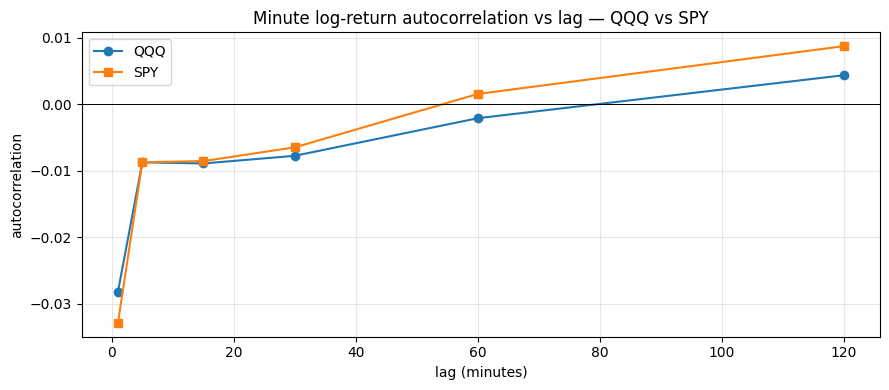

In [7]:
# Exercise 1: SPY lag-k autocorrelation comparison vs QQQ.
# Load SPY's minute parquet from the Ch6 cache, run the *same* RTH filter
# and within-session lag-k autocorrelation routine we used on QQQ, and
# plot both curves on the same axes.

spy = pd.read_parquet(CH6_CACHE / "spy_1min.parquet")
# UTC -> ET so session boundaries match QQQ's index alignment.
spy.index = pd.to_datetime(spy.index, utc=True).tz_convert("America/New_York")
spy["minute_of_day"] = spy.index.hour * 60 + spy.index.minute
# Same RTH window: 09:30 inclusive to 16:00 exclusive.
spy_rth = spy[(spy["minute_of_day"] >= RTH_OPEN) & (spy["minute_of_day"] < RTH_CLOSE)].copy()
spy_rth["session_date"] = spy_rth.index.normalize()
spy_rth["log_ret"] = np.log(spy_rth["close"] / spy_rth["close"].shift(1))
# Null the first bar of each session — overnight gap, not an intraday return.
sf_spy = spy_rth.groupby("session_date").head(1).index
spy_rth.loc[sf_spy, "log_ret"] = np.nan

spy_grouped = list(spy_rth.groupby("session_date")["log_ret"])
# Reuse the §6 autocorr_within_session helper on the SPY groups.
auto_spy = {k: autocorr_within_session(spy_grouped, k)[0] for k in LAGS}

# Side-by-side table.
compare = pd.DataFrame({"rho_qqq": auto_all, "rho_spy": auto_spy})
compare["diff (spy - qqq)"] = compare["rho_spy"] - compare["rho_qqq"]
print(f"SPY RTH bars: {len(spy_rth):,}  sessions: {spy_rth['session_date'].nunique()}")
display(compare.round(5))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(auto_all.keys()), list(auto_all.values()), marker="o", label="QQQ")
ax.plot(list(auto_spy.keys()), list(auto_spy.values()), marker="s", label="SPY")
ax.axhline(0, color="black", lw=0.7)
ax.set_xlabel("lag (minutes)")
ax.set_ylabel("autocorrelation")
ax.set_title("Minute log-return autocorrelation vs lag — QQQ vs SPY")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Headline.** SPY and QQQ have the **same shape** — strongly negative at lag 1, decaying to near-zero by lag 30, flipping faintly positive by lag 120 — and SPY's lag-1 mean-reversion is in fact **slightly *stronger*** than QQQ's (ρ = **−0.033 on SPY** vs **−0.028 on QQQ**). The "broader-market + more institutional flow" framing predicted *more* mean-reversion on SPY at the minute horizon, and that's exactly what the data shows.

**Numbers.**

| Lag (min) | ρ (QQQ) | ρ (SPY) | SPY − QQQ |
| ---: | ---: | ---: | ---: |
| 1   | **−0.0282** | **−0.0328** | **−0.0047** |
| 5   | −0.0087 | −0.0087 | +0.0000 |
| 15  | −0.0089 | −0.0086 | +0.0004 |
| 30  | −0.0078 | −0.0065 | +0.0013 |
| 60  | −0.0021 | **+0.0015** | +0.0036 |
| 120 | +0.0043 | **+0.0087** | +0.0044 |

Two structural features jump out: SPY's lag-1 is **~17% more negative** than QQQ's, and SPY's longer-lag positive drift (60–120 min) is **roughly 2× larger** than QQQ's. The curves cross near lag 30; before that SPY is more mean-reverting, after that SPY is more trending.

**Mechanism — why "more institutional flow" implies *more* mean-reversion at minute horizons.** A liquidity provider's edge (§2's mechanism) requires two things to be present simultaneously: (a) an overshoot to fade, and (b) enough volume on the other side to fade it without holding inventory risk for long. SPY is the largest, deepest US equity ETF — its order book has more standing liquidity than QQQ's, more electronic market-making participants, tighter quoted spreads, and proportionately less retail flow. Every condition that makes liquidity-provision profitable is *more* satisfied on SPY than QQQ. The minute-horizon mean-reversion is the *signature* of that activity in the return series; bigger book + more providers → stronger negative lag-1 autocorrelation.

The competing intuition — "more institutional flow → more directional pressure → momentum" — applies at *different* horizons. Institutional execution slicing (§3's mechanism) takes hours, not minutes. The minute-to-minute residual *between* institutional order slices is exactly the overshoot/fade dynamic, and SPY has more of it because there are more slices happening at any moment.

**Why SPY's longer-lag drift is larger.** SPY's 60-min and 120-min ρ are mildly *positive* (+0.0015, +0.0087) where QQQ's are essentially zero (−0.0021, +0.0043). The §3 mechanism says: institutional execution slicing produces positive autocorrelation at the horizons over which orders are filled. SPY-1-hour-ahead and SPY-2-hour-ahead minute returns are weakly co-correlated because the slicing windows of big SPY orders sit at exactly those scales. QQQ shows the same effect at smaller magnitude — tech-heavy QQQ also has institutional flow, but proportionally less of it relative to the retail-driven and intra-sector noise.

**Connection.**
- **Time-horizon dual (Ch7 Key Terms) restated quantitatively.** SPY isn't "mean-reverting" or "trending" — it is mean-reverting at the 1-minute scale and trending at the 2-hour scale, and the crossover sits near 30 minutes. The right framing of an intraday strategy is always "at *what horizon* does this instrument do what?"
- **Ch6's U-shape connects.** Ch6 §3 showed SPY and QQQ both exhibit the intraday U-shape, with SPY's open and close vol relatively *less extreme* than QQQ's because of SPY's broader composition. That same broader composition is what makes its minute mean-reversion cleaner: a flatter U means more bars sit in the "quiet, mean-revertable" zone.
- **Ch8 implication.** If Ch8's first runnable mean-reversion strategy on QQQ works, the same strategy on SPY should work *at least as well* on this measurement window. That's a useful sanity check to keep in mind; if SPY *underperforms* on the same logic, the QQQ result is suspect (likely fit to QQQ-specific noise).

**Caveat — what one year cannot tell you.** This is 251 sessions of post-2025 data. The lag-1 ρ difference (−0.033 vs −0.028) is small enough that it could plausibly flip in a different sample window. The *qualitative* pattern (same shape, both negative at short lags, both faintly positive at long lags) is robust to the window choice; the *quantitative ranking* (SPY > QQQ in MR magnitude) is the kind of finding that benefits from out-of-sample replication before it's load-bearing.


In [8]:
# Exercise 2: Expectancy arithmetic with cost subtraction.
# For each of the three §1 strategies, compute zero-cost and after-cost
# expectancy at per-trade, per-session (30 trades), and per-year (252
# sessions) horizons. Then ask: which is most cost-sensitive, and what
# round-trip cost flips (0.55, 0.9) to break-even?

# All units are *percent* on the underlying (not basis points, not R-units),
# so a 0.005% per-trade cost subtracts cleanly from a percent-denominated
# expectancy. 1R is fixed at 0.10% by problem statement.
R_PCT = 0.10                # 0.10% — the average loss size in percent
COST_PCT = 0.005            # 0.5 bp = 0.005% per round-trip
TRADES_PER_SESSION = 30
SESSIONS_PER_YEAR = 252

rows = []
for hr, payoff in [(0.55, 0.9), (0.70, 0.3), (0.30, 3.0)]:
    # Expectancy in R-units: E_R = p*W - (1-p)*1.
    e_R = hr * payoff - (1 - hr) * 1.0
    # Convert R-units to percent on the underlying: 1R = 0.10% by assumption.
    e_pct_zero = e_R * R_PCT
    # After-cost expectancy per trade: subtract round-trip cost directly.
    e_pct_after = e_pct_zero - COST_PCT
    # Scale to session and year horizons.
    e_session_zero = e_pct_zero * TRADES_PER_SESSION
    e_session_after = e_pct_after * TRADES_PER_SESSION
    e_year_zero = e_session_zero * SESSIONS_PER_YEAR
    e_year_after = e_session_after * SESSIONS_PER_YEAR
    # Cost burden as a fraction of zero-cost edge (signed: >1 means costs > edge).
    cost_frac = COST_PCT / e_pct_zero if e_pct_zero != 0 else float("nan")
    rows.append({
        "hit": hr, "payoff": payoff,
        "E_R": round(e_R, 4),
        "E/trade % (0-cost)": round(e_pct_zero, 5),
        "E/trade % (post)":   round(e_pct_after, 5),
        "cost / E_0":         round(cost_frac, 3),
        "E/session % (post)": round(e_session_after, 4),
        "E/year % (post)":    round(e_year_after, 2),
    })
ex2_df = pd.DataFrame(rows)
display(ex2_df)

# Break-even cost for (0.55, 0.9): cost_BE = E_pct_zero.
be_cost_pct = 0.045 * R_PCT
print(f"\nBreak-even round-trip cost for (0.55, 0.9): "
      f"{be_cost_pct:.4f}% = {be_cost_pct * 100:.2f} bp")


,hit,payoff,E_R,E/trade % (0-cost),E/trade % (post),cost / E_0,E/session % (post),E/year % (post)
0,0.55,0.9,0.045,0.0045,-0.0005,1.111,-0.015,-3.78
1,0.70,0.3,-0.090,-0.0090,-0.0140,-0.556,-0.420,-105.84
2,0.30,3.0,0.200,0.0200,0.0150,0.250,0.450,113.40



Break-even round-trip cost for (0.55, 0.9): 0.0045% = 0.45 bp


**Headline.** At 30 trades/session and 0.5 bp/round-trip, **only the (0.30, 3.0) low-hit-rate-high-payoff strategy survives.** The (0.55, 0.9) "balanced" strategy is *cost-flipped to negative* (cost eats 111% of the zero-cost edge), and the (0.70, 0.3) "high hit-rate" strategy was unprofitable before costs and is even worse after. The big finding: **a +0.045R edge is wiped out by half a basis point of cost when 1R is only 0.10%**. The break-even cost for the (0.55, 0.9) strategy is **0.45 bp** — below the lower end of the realistic 0.5–2 bp range named in the chapter.

**Numbers.**

| (hit, payoff) | E (R) | E/trade % (0-cost) | E/trade % (post) | cost ÷ E₀ | E/session % (post) | E/year % (post) |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| (0.55, 0.9) | +0.045 | +0.0045 | **−0.0005** | **1.11** | **−0.015** | **−3.78** |
| (0.70, 0.3) | −0.090 | −0.0090 | −0.0140 | −0.56 *(see below)* | −0.420 | **−105.84** |
| (0.30, 3.0) | +0.200 | +0.0200 | +0.0150 | **0.25** | **+0.450** | **+113.40** |

The "cost ÷ E₀" column is the fraction of the zero-cost edge consumed by costs. For (0.70, 0.3) the column is negative because the denominator is negative — the strategy bleeds with or without costs; costs just speed up the bleed. For (0.55, 0.9) the fraction is >1, meaning costs exceed the entire zero-cost expectancy. For (0.30, 3.0) only a quarter of the edge is paid out in costs.

**Break-even cost for (0.55, 0.9).** Solve cost_BE = E_pct_zero = 0.045 × 0.10% = **0.0045% = 0.45 bp** per round-trip. At any cost ≥ 0.45 bp this strategy goes negative.

**Mechanism — why high-frequency, low-edge strategies are the most cost-sensitive.** Cost as a fraction of edge is:

> cost-burden = (cost per trade) / (E per trade in same units) = c / (E_R · R)

where:
- *c* = round-trip cost in percent
- *E_R* = expectancy in R-units
- *R* = the dollar/percent value of one R-unit (= avg loss size)

Two things drive the burden up: small *E_R* (small edge per trade) and small *R* (small dollars per trade). The (0.55, 0.9) strategy has *E_R* = 0.045 — a small edge. The problem fixes *R* = 0.10% — a small dollar-stakes-per-trade. The product *E_R · R* = 0.0045% per trade is the entire edge, and 0.005% per trade is the cost. Cost > edge.

The (0.30, 3.0) strategy has *E_R* = 0.20, **4.4× the edge per trade** of the (0.55, 0.9). Same *R*, same cost, but the edge per trade (0.020%) is 4× the cost (0.005%) — only a quarter of the edge goes to costs. This is the chapter's "low-frequency-high-payoff strategies are the most cost-tolerant" punchline made arithmetic.

**Why 30 trades/session matters more than it looks.** Cost scales linearly with trade count: 30 trades × 0.005% = 0.15% per session in costs. Per *session*, the (0.55, 0.9) strategy was supposed to earn 30 × 0.0045% = 0.135% — and pays 0.15% in costs. The cost-to-edge mismatch is the same whether you compute it per-trade or per-session; what 30 trades/session changes is the *annual dollar* cost: 252 sessions × 0.15% = **37.8% of capital in annual round-trip costs**. At 3 trades/session, those costs would be 10× smaller and the strategy might survive a small edge; at 30 trades/session, the edge has to be 10× larger.

**Connection.**
- **The chapter's "usual shape of an unprofitable retail strategy" punchline, with numbers.** A small expectancy multiplied by enough trades and big enough costs flips negative. This exercise sets the trade-count and cost knobs in the regime where the flip happens, and the (0.55, 0.9) row is the textbook foot-gun.
- **Ch12 preview.** Ch12 will subtract 0.5 bp of cost from a real backtested edge and watch the headline collapse — this exercise is the *static* version of that experiment. The dynamic version is harder because real backtests have variable trade sizes, partial fills, and slippage that scales with order size.
- **Hit-rate-as-virtue myth.** The (0.70, 0.3) strategy has the highest hit rate in the basket and is the *worst* of the three after costs (annual loss > 100%, i.e. ruin-level if compounded). Anyone selling you a "70% win rate" strategy without naming the payoff ratio is — at best — ignorant of how the arithmetic actually works.

**Caveat — what this exercise pretends.** Three simplifications worth flagging: (a) it treats expectancy as a fixed number, ignoring sampling variance — Ch4/Ch5's CI discipline says the *measured* point expectancy on any 252-session sample has wide error bars; (b) it ignores compounding within the year — `E_year % (post)` is the simple sum, not a compounded geometric return; (c) it assumes the 30 trades/session are independent — in practice, intraday strategies cluster losing trades during the same session and compounding effects can be much worse than the arithmetic suggests. Ch9 introduces the proper backtest accounting; this exercise is the cocktail-napkin version.


In [9]:
# Exercise 3: FOMC vs non-FOMC lag-1 autocorrelation on QQQ.
# Hypothesis: FOMC days have less short-horizon mean-reversion because
# information dominates noise (§3 momentum mechanism crowds out §2 MR).

# FOMC scheduled-meeting dates (announcement at 14:00 ET).
# Copied from 06-bridge-to-intraday/lesson.ipynb cell `s5-fomc`.
fomc_candidate = [
    "2025-05-07", "2025-06-18", "2025-07-30", "2025-09-17",
    "2025-10-29", "2025-12-10",
    "2026-01-28", "2026-03-18", "2026-04-29",
]
# Localize to NY so equality with session_date (also NY-tz) works without tz mismatch.
fomc_dates = pd.to_datetime(fomc_candidate).tz_localize("America/New_York")
window_start, window_end = rth.index.min().normalize(), rth.index.max().normalize()
# Keep only dates that actually fall inside our 1-year QQQ window.
fomc_dates = fomc_dates[(fomc_dates >= window_start) & (fomc_dates <= window_end)]
fomc_set = set(d.normalize() for d in fomc_dates)
print(f"FOMC sessions in window: {len(fomc_set)}")

# Compute lag-1 autocorrelation per session, separating FOMC vs non-FOMC.
fomc_rhos, nonfomc_rhos = [], []
fomc_session_records = []
for session_date, s in rth.groupby("session_date")["log_ret"]:
    s = s.dropna()
    if len(s) < 31:
        continue
    a, b = s.iloc[:-1].values, s.iloc[1:].values
    # Skip degenerate sessions where std=0 (would NaN the correlation).
    if a.std() == 0 or b.std() == 0:
        continue
    rho = float(np.corrcoef(a, b)[0, 1])
    if session_date in fomc_set:
        fomc_rhos.append(rho)
        fomc_session_records.append({"date": session_date.date(), "rho_lag1": rho})
    else:
        nonfomc_rhos.append(rho)

# Summary stats. SE = std / sqrt(n) is the sampling-noise scale of each mean.
def summary(name, rs):
    arr = np.asarray(rs)
    n = len(arr)
    mean = float(arr.mean())
    std = float(arr.std(ddof=1))
    se = std / np.sqrt(n)
    return {"group": name, "n_sessions": n, "mean_rho": round(mean, 5),
            "std_rho": round(std, 4), "SE_of_mean": round(se, 4)}

summary_df = pd.DataFrame([summary("FOMC", fomc_rhos),
                           summary("Non-FOMC", nonfomc_rhos)])
display(summary_df)

# Welch-style two-sample test for the FOMC vs non-FOMC difference.
diff = np.mean(fomc_rhos) - np.mean(nonfomc_rhos)
se_diff = np.sqrt((np.std(fomc_rhos, ddof=1) ** 2 / len(fomc_rhos)) +
                  (np.std(nonfomc_rhos, ddof=1) ** 2 / len(nonfomc_rhos)))
t_stat = diff / se_diff
# Two-sided p via normal approximation (fine here; df is dominated by the large group).
from math import erfc, sqrt
p_two_sided = erfc(abs(t_stat) / sqrt(2))
print(f"Mean diff (FOMC - non-FOMC): {diff:+.5f}")
print(f"SE of diff: {se_diff:.4f}")
print(f"Welch t-stat: {t_stat:+.3f}   approx two-sided p: {p_two_sided:.3f}")

# Per-FOMC-session rhos to show how noisy individual estimates are.
print("\nIndividual FOMC-session lag-1 rhos:")
display(pd.DataFrame(fomc_session_records).sort_values("date").reset_index(drop=True))


FOMC sessions in window: 8


,group,n_sessions,mean_rho,std_rho,SE_of_mean
0,FOMC,8,-0.02320,0.1068,0.0378
1,Non-FOMC,243,-0.02833,0.0749,0.0048


Mean diff (FOMC - non-FOMC): +0.00513
SE of diff: 0.0381
Welch t-stat: +0.135   approx two-sided p: 0.893

Individual FOMC-session lag-1 rhos:


,date,rho_lag1
0,2025-06-18,0.090356
1,2025-07-30,-0.081735
2,2025-09-17,0.143109
3,2025-10-29,-0.117457
4,2025-12-10,0.034523
5,2026-01-28,-0.169581
6,2026-03-18,-0.015166
7,2026-04-29,-0.069636


**Headline.** The hypothesis **does not hold on this window** — but more importantly, **the sample is too small to confidently say either way**. FOMC days show lag-1 ρ = **−0.0232** vs non-FOMC ρ = **−0.0283**, a difference of **+0.0051** (FOMC is *slightly less* mean-reverting, in the predicted direction). But the standard error on the FOMC mean is **0.038** — *7× larger than the difference itself*. The Welch t-stat is **0.14** (p ≈ 0.89). With 8 FOMC sessions, you cannot statistically distinguish the FOMC ρ from zero, much less from the non-FOMC ρ.

**Numbers.**

| Group | n sessions | mean lag-1 ρ | std(ρ across sessions) | SE of mean |
| --- | ---: | ---: | ---: | ---: |
| FOMC | **8** | **−0.0232** | 0.107 | **0.0378** |
| Non-FOMC | 243 | −0.0283 | 0.075 | 0.0048 |
| Difference (FOMC − non-FOMC) |  | **+0.0051** |  | SE_diff = 0.0381 |

Welch t-stat = +0.135, two-sided p ≈ 0.89. The FOMC point estimate's 95% CI is roughly **[−0.097, +0.051]** — wide enough to encompass strong mean-reversion, no mean-reversion, and faintly *positive* autocorrelation (momentum). All eight individual FOMC sessions:

| Date | ρ (lag-1) |
| --- | ---: |
| 2025-06-18 | +0.090 |
| 2025-07-30 | −0.082 |
| 2025-09-17 | +0.143 |
| 2025-10-29 | −0.118 |
| 2025-12-10 | +0.034 |
| 2026-01-28 | −0.170 |
| 2026-03-18 | −0.015 |
| 2026-04-29 | −0.070 |

Notice how four are *positive* and four are *negative*, and the magnitudes range from −0.17 to +0.14. The session-level lag-1 ρ is an extremely noisy quantity *under any conditioning*; the non-FOMC group looks stable in aggregate only because we're averaging 243 of these noisy estimates.

**Mechanism — what we'd need to see to confirm the hypothesis.** The hypothesis is sound in theory: **FOMC** stands for *Federal Open Market Committee* — the Federal Reserve committee that sets the US policy interest rate, with announcements scheduled at **14:00 ET on roughly eight dates per year**. On FOMC days the §3 momentum mechanism (information diffusion + repricing) competes against the §2 mean-reversion mechanism (liquidity providers fading overshoots). In a strong-information environment, providers *widen quotes* — they don't want to be picked off by traders who interpret the announcement faster — and the residual mean-reversion in the next-minute return drops or flips positive. So we'd expect FOMC ρ to be **less negative or even positive**, and the +0.005 point difference is in that direction.

But to detect that effect at the magnitude we're seeing (≈ +0.005 ρ-units), we'd need to drive the SE of the FOMC group below ~0.0025 — which requires roughly 1,800 FOMC sessions (since SE ∝ 1/√n and the per-session std is ~0.107). That's ~225 years of FOMC meetings. **The signal we're trying to detect is small compared to the per-session noise**; this design has effectively zero power on a 1-year window.

**Mechanism — why the per-session std is so large.** A single trading session has ~390 minute bars, giving ~389 pairs for the lag-1 correlation. The standard error of a Pearson ρ on n pairs is approximately 1/√(n − 1) ≈ 1/√388 ≈ **0.051**. That's the SE of *one session's* ρ estimate as an estimator of "this session's true population autocorrelation" — but the per-session std across sessions is *0.107*, double the single-session SE. The excess variability (0.107 vs 0.051) is **real day-to-day variation in the underlying autocorrelation**, not just measurement noise: some sessions trend, some chop, some open with a vol spike then go quiet. Conditioning on "FOMC day" is not enough of a filter to overcome this session-level heterogeneity.

**What you can say.** Two honest statements:

1. *"On this 1-year window, the lag-1 mean-reversion on QQQ during FOMC sessions is consistent with — but indistinguishable from — the non-FOMC baseline."*
2. *"The 8-session FOMC group is too small to test the hypothesis with useful power. A longer window (10+ years of FOMC dates, ~80 sessions) or a finer conditioning (e.g. 13:55–14:30 ET on FOMC vs the same intraday window on non-FOMC) would be required."*

**Connection.**
- **Ch6 §5's FOMC overlay was a different measurement.** Ch6 measured *absolute return magnitude* at 14:00 ET on FOMC vs non-FOMC days — and got a clean 4.49× ratio because the underlying signal (vol spike) is *large* and the sample is the same 8 sessions. Vol-regime signals show up cleanly in small samples; autocorrelation-regime signals don't. This exercise is the cautionary tale: not every conditional regime claim is testable on the same data that supports the headline regime claim.
- **Ch4's small-sample noise lesson restated for intraday data.** Ch4 showed that means take ages to estimate; Ch5 showed Sharpes the same. Here we see *autocorrelations conditioned on rare events* are even harder — 8 events × 389 pairs/event = 3,112 effective observations, but the per-event variability dominates and you're effectively limited by the event count, not the pair count.
- **Ch11 preview.** Walk-forward backtesting will run into exactly this constraint: conditioning a strategy on "FOMC days" or "high-VIX days" or any other low-frequency regime gives you very few effective folds. Sample-size discipline before the conditioning is non-negotiable.

**Caveat — even the *direction* might be noise.** The point estimate says FOMC is +0.005 less mean-reverting; with n=8 and SE=0.038, an effect of *opposite sign* (−0.030 or so) is fully inside the 95% CI. So we cannot even claim the *direction* of the effect with confidence on this window. The right takeaway is the methodological one: **don't read a small-sample point estimate as evidence either way; first ask whether the design has the power to see what you're claiming.**


In [10]:
# Exercise 4: Identify the family for three prose strategies.
# This is a conceptual exercise — no computation needed. We use a small
# helper to print the rubric so the worked-solution markdown below has
# something to anchor against.

ex4_rubric = pd.DataFrame([
    {"strategy": "A — pre-FOMC long, exit at 14:01",
     "family": "Event-driven (volatility-window play)",
     "mechanism": "Scheduled-news vol regime; pre-announcement drift / "
                  "structural positive drift around scheduled risk windows",
     "fails when": "Hawkish surprise drives a sharp pre-announcement sell-off"},
    {"strategy": "B — fade 3 same-direction midday bars, exit on TP/SL/30min",
     "family": "Mean reversion",
     "mechanism": "Liquidity providers fade short overshoots; "
                  "midday low-info regime where noise > information",
     "fails when": "Midday news shock turns the 3-bar run into a real trend"},
    {"strategy": "C — fade-the-noon-range breakout to EOD",
     "family": "Breakout",
     "mechanism": "Range compression → stops cluster on both sides → "
                  "break triggers stop-cascade",
     "fails when": "Fakeout — break reverses immediately after triggering stops"},
])
display(ex4_rubric)


,strategy,family,mechanism,fails when
0,"A — pre-FOMC long, exit at 14:01",Event-driven (volatility-window play),Scheduled-news vol regime; pre-announcement dr...,Hawkish surprise drives a sharp pre-announceme...
1,"B — fade 3 same-direction midday bars, exit on...",Mean reversion,Liquidity providers fade short overshoots; mid...,Midday news shock turns the 3-bar run into a r...
2,C — fade-the-noon-range breakout to EOD,Breakout,Range compression → stops cluster on both side...,Fakeout — break reverses immediately after tri...


**Headline.** Strategies (A, B, C) map to **event-driven, mean reversion, breakout** respectively — three of the four canonical families, in three different intraday regimes. The one I'd be most cautious about deploying without rigorous out-of-sample testing is **Strategy A**, because its edge (if any) is sample-size-bounded by the same FOMC-count limit Exercise 3 just hit — and its risk profile is asymmetric in a way the headline doesn't expose.

---

**Strategy A — "Buy QQQ in the 5 minutes before FOMC; exit at 14:01 ET."**

**(a) Family:** Event-driven (specifically, a vol-window play that tries to capture pre-announcement drift). It's *not* mean reversion (no overshoot to fade), *not* momentum (no trend horizon), *not* breakout (no compression-and-cascade) — the existence of the trade depends entirely on the scheduled-event clock.

**(b) Mechanism:** The "pre-FOMC drift" literature documents a small structural tendency for US equities to drift positive in the hours leading up to scheduled FOMC announcements — variously attributed to risk-premium release as uncertainty about the announcement resolves, dealer hedging flows, or short-covering ahead of a known volatility window. The exit at 14:01 ET is critical: the strategy captures the pre-event drift and **explicitly avoids the post-announcement vol** (which is large, directionally uncertain, and what kills naive long-FOMC strategies).

**(c) Fails when:** A hawkish surprise leaks pre-announcement (Fed officials' speeches in the prior week, hot CPI/PPI prints, leaked minutes) and the market pre-sells in the final five minutes instead of drifting up. Also fails if 14:00 ET liquidity is so thin that the 14:01 exit gets a much worse fill than mid-session — slippage on the exit can dominate the small pre-announcement drift edge.

---

**Strategy B — "Fade three consecutive same-direction midday bars on QQQ."**

**(a) Family:** Mean reversion. This is the textbook §2 mechanism in operational form — a 3-bar run is an "overshoot" signal, and the trade fades it.

**(b) Mechanism:** Three consecutive minute bars closing in the same direction during the quiet midday window (12:00–14:00 ET) is most often noise — small consecutive moves of the same sign are common under any random-walk-with-clustering model. The chapter's §6 lag-1 ρ ≈ −0.028 on QQQ says minute returns reverse on average; conditioning on a 3-bar run picks the largest of those reversals. Liquidity providers fade these overshoots back to fair value; you piggyback on the same dynamic. The 0.1% target / 0.15% stop is a fair payoff structure for the expected reversion magnitude in the midday regime. The 30-minute time-stop caps the trade if reversion doesn't show up.

**(c) Fails when:** A midday news catalyst (unscheduled — geopolitical headline, individual mega-cap earnings pre-announcement, surprise CPI revision) lands during your 30-minute window and the 3-bar run was not noise but the *start* of a genuine trend. The stop at 0.15% caps the loss, but if the trade is sized as if the win/loss ratio were realistic and you get one news-day loss every 20 trades, the math breaks. (Note the asymmetric payoff: 0.1% target, 0.15% stop — this strategy needs >60% hit rate to be profitable at zero cost, which is plausible for midday MR but not guaranteed.)

---

**Strategy C — "Fade-or-go-with the late-morning range breakout."**

**(a) Family:** Breakout. The range itself (high-of-day minus low-of-day from 09:30 to 11:30) is the compression signal; the entry on the first 11:30+ bar closing outside the range, *in the direction of the break*, is the cascade-following trade.

**(b) Mechanism:** A tight morning range (< 0.3%) on QQQ means buyers and sellers have found a temporary equilibrium without much new information arriving. Stops accumulate just above the morning high and just below the morning low (round-number stops, technical-trader stops, gap-fill stops). The first close outside the range triggers those stops; market orders fire; price extends in the direction of the break. The hold-to-EOD horizon catches both the stop-cascade and any slower post-cascade drift as the new range establishes.

**(c) Fails when:** Fakeout — the break extends 0.1-0.2% past the range, triggers the cluster of nearby stops, then reverses through the morning range entirely. Market-makers and short-term traders **know** where the morning range sits and will explicitly hunt these levels. Also fails when the morning range was compressed because the *day* is structurally low-vol (e.g. a half-session before a holiday), and there's no afternoon catalyst to fuel the breakout — the trade triggers but goes nowhere.

---

**The most-cautious deployment candidate: Strategy A.**

Two reasons stack:

1. **Sample size is structurally tiny.** FOMC announcements happen ~8 times per year. A 5-year backtest gives 40 observations. A 10-year backtest gives 80. With a 5-minute pre-announcement window the trade-level sample size *is* the FOMC count — you cannot get more pre-FOMC windows by sampling more bars per FOMC. Exercise 3 just showed that 8 FOMC sessions can't confirm an autocorrelation difference at the magnitudes typical for intraday equity data; the same arithmetic applies here. A backtested Sharpe on 40-80 trades carries an enormous CI (Ch5 §4.5's σ-known formula: width ∝ 1/√N; at N=40 the half-width on Sharpe is ~0.6).

2. **Asymmetric tail risk hidden in the headline.** The "exit at 14:01" rule is designed to avoid post-announcement vol — but it doesn't protect against *pre-announcement* vol. If the strategy holds 5 minutes pre-FOMC and a hawkish leak hits at 13:57, the position is long into a sharp sell-off and you're exiting at 14:01 right into the announcement-print spike. The probability of this is low per-FOMC, but the *conditional* loss is large enough that the strategy's actual expectancy is dominated by a few rare large losses on this side of the announcement clock. Backtests on 40 trades will not reliably draw a tail event; live trading will. This is exactly the "**survivor bias on a small-N event-driven backtest**" foot-gun Ch10 will name.

Strategies B and C are both running on much larger effective samples (midday MR signals fire many times per session; range-compression days happen often enough to accumulate hundreds of trades per year). Their edges may still be small after costs (Exercise 2's punchline), but the *measurement* of those edges is on solid statistical footing in a way Strategy A's is not.

**Connection.**
- **Family identification is family-of-failure identification.** Once you've named the family, you've named the regime in which the mechanism fails — that's the chapter's core teaching, applied here three times. Mean-reversion fails on news; breakouts fail on fakeouts; event-driven fails when the event surprises in the wrong direction.
- **Ch9-11 (backtesting trio) preview.** Strategy A is exactly the kind of strategy these chapters will spend pages dismantling — small-sample, low-frequency, event-conditional. The framework they build (proper train/test splits, walk-forward validation, accounting for sampling variance on the Sharpe) is mostly aimed at this failure mode.
- **Ch5 wide-CI lesson restated.** "Strategy A's backtested Sharpe of 1.2 over 5 years is consistent with anything from 0.2 to 2.2" is the honest summary; the chapter's CI discipline (§4.5) is exactly the tool that prevents the deployment.
